In [6]:
import networkx as nx

In [7]:
graph = nx.read_gexf("labeled_graph.gexf")

In [8]:
from collections import defaultdict

graphs = defaultdict(lambda:nx.Graph())

for a, b, data in graph.edges(data=True):
    graphs[data["subreddit"]].add_edge(a, b, weight = data["weight"])

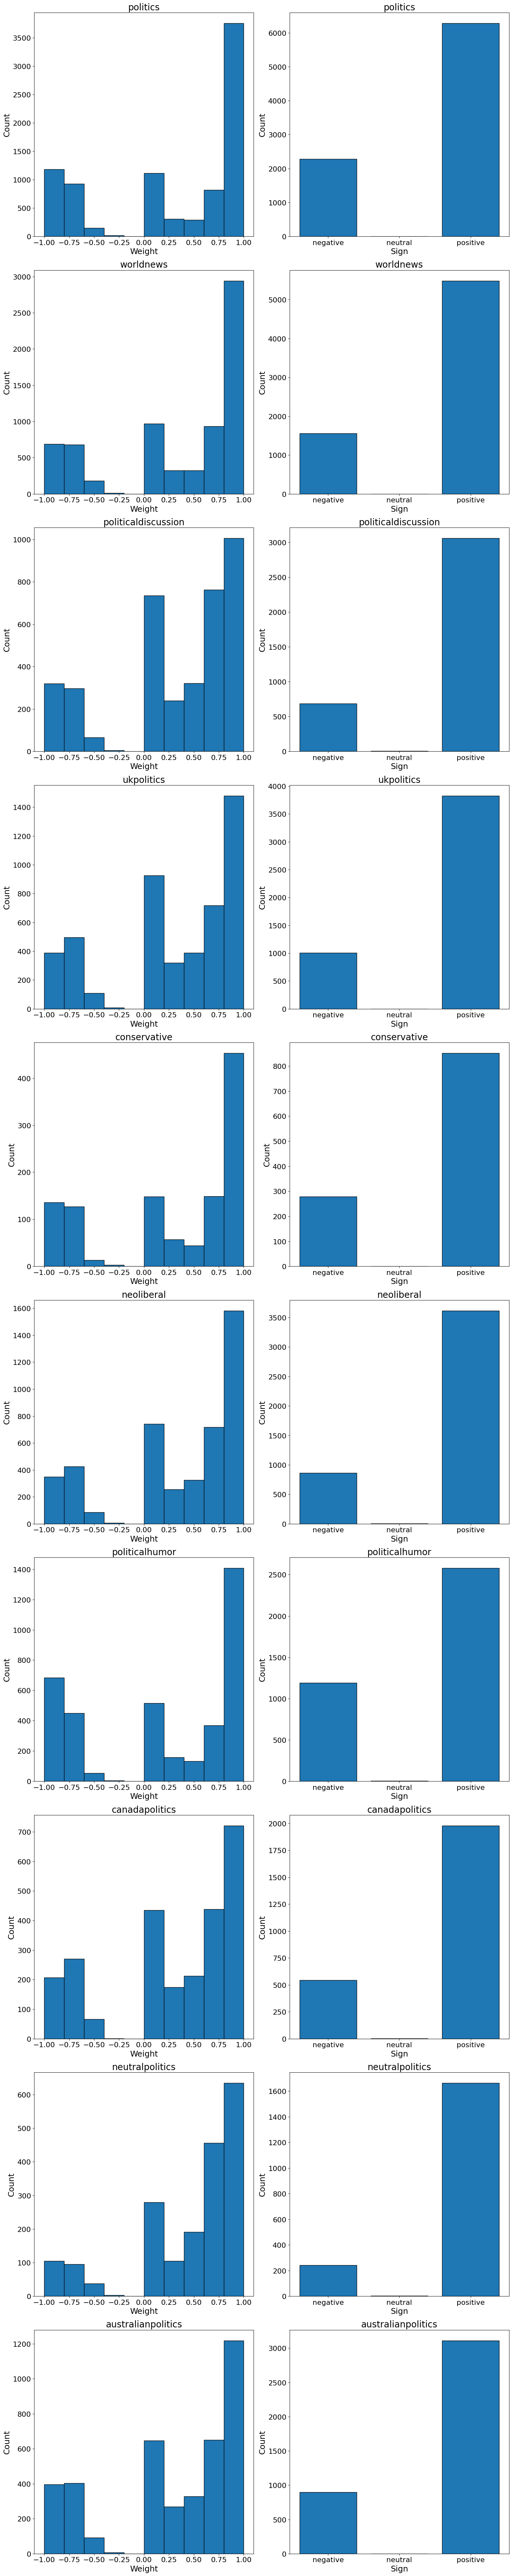

In [12]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(len(graphs), 2, figsize=(16, 8 * len(graphs)))

for ind, subreddit in enumerate(graphs):
    axes[ind][0].set_title(subreddit, fontsize=20)
    axes[ind][1].set_title(subreddit, fontsize=20)
    w = np.array([data["weight"] for a, b, data in graphs[subreddit].edges(data=True)])
    axes[ind][0].hist(w, edgecolor="black")
    axes[ind][1].hist(np.sign(w), edgecolor="black", bins=[-1.5, -0.5, 0.5, 1.5], rwidth=0.8)
    axes[ind][1].set_xticks([-1, 0, 1])
    axes[ind][1].set_xticklabels(["negative", "neutral", "positive"], fontsize=16)
    axes[ind][0].tick_params(axis='both', labelsize=16)
    axes[ind][1].tick_params(axis='both', labelsize=16)
    axes[ind][0].set_xlabel("Weight", fontsize=18)
    axes[ind][0].set_ylabel("Count", fontsize=18)
    axes[ind][1].set_xlabel("Sign", fontsize=18)
    axes[ind][1].set_ylabel("Count", fontsize=18)



plt.tight_layout()
plt.show()